# WorldCover viz

This notebook is used to provide a visualizaztion of the raster created with the WorldCover data for the AOI:

In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import os
import sys

sys.path.append(os.path.abspath(".."))

In [30]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import rasterio

from lulc.config import load_config
from lulc.io import GLOBAL_CONFIG, WORLDCOVER_LABELS
from lulc.viz.colors import normalize_rgb
from lulc.viz.images import store_figure

In [10]:
config = load_config(GLOBAL_CONFIG)

In [24]:
cn = config.worldcover.class_names
ctc = config.worldcover.class_to_color

In [19]:
ctc

{0: [255, 255, 255],
 1: [0, 100, 0],
 2: [255, 187, 34],
 3: [255, 255, 76],
 4: [240, 150, 255],
 5: [250, 0, 0],
 6: [180, 180, 180],
 7: [240, 240, 240],
 8: [0, 100, 200],
 9: [0, 150, 160],
 10: [0, 207, 117],
 11: [250, 230, 160]}

In [25]:
cn

{0: 'No Data',
 1: 'Tree Cover',
 2: 'Shrubland',
 3: 'Grassland',
 4: 'Cropland',
 5: 'Built-up',
 6: 'Bare/Sparse vegetation',
 7: 'Snow and ice',
 8: 'Permanent water bodies',
 9: 'Herbaceous wetland',
 10: 'Mangroves',
 11: 'Moss and lichen'}

In [6]:
with rasterio.open(WORLDCOVER_LABELS, "r") as src:
    labels = src.read()

In [23]:
np.unique(labels)

array([1, 2, 3, 4, 5, 6, 8, 9], dtype=uint8)

In [57]:
NUM_CLASSES = len(config.worldcover.class_names)

colors = [normalize_rgb(ctc.get(idx, (0, 0, 0))) for idx in range(NUM_CLASSES)]
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries=range(NUM_CLASSES + 1), ncolors=NUM_CLASSES)

patches = [
    mpatches.Patch(
        facecolor=normalize_rgb(ctc.get(idx, (0, 0, 0))),
        label=f"{cn.get(idx, (''))}",
        edgecolor="black",
        linewidth=1,
    )
    for idx in range(NUM_CLASSES)
]

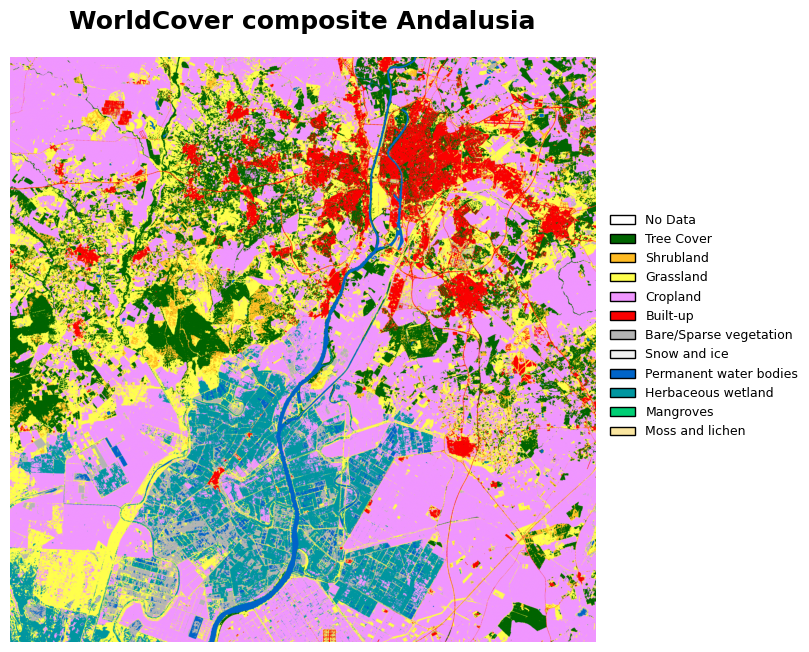

In [84]:
title = f"WorldCover composite {config.aoi.selected.name.title()}"

fig, ax = plt.subplots(figsize=(8, 8), layout="constrained")

ax.imshow(labels[0, :, :], cmap=cmap, norm=norm)

# Suptitle centers on the entire figure
# plt.suptitle(
#    title,
#    fontsize=18,
#    fontweight="bold",
#    color="black"
# )
ax.set_title(title, fontsize=18, fontweight="bold", color="black", pad=20)
fig.legend(
    # Without the layout=contrained allows to set it below the figure
    #    handles=patches, loc="upper center", ncols=NUM_CLASSES / 3, bbox_to_anchor=(0.5, -0.01), frameon=False, fontsize=9
    handles=patches,
    ncols=1,
    loc="outside right center",
    frameon=False,
    fontsize=9,
)
ax.axis("off")

store_figure(title)

# plt.tight_layout(pad=1.5, h_pad=1, w_pad=1)